In [1]:
import pandas as pd
df = pd.read_csv("marketing_AB.csv")
df.head(5)

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
df=pd.read_csv("marketing_AB.csv", index_col = 0)

In [3]:
df.head(5)

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 27.5+ MB


In [5]:
df['test group'].value_counts()
df['converted'].value_counts()

,count
converted,
False,573258
True,14843


In [6]:
df.shape

(588101, 6)

In [7]:
len(df)

588101

In [8]:
# Check group distribution
df['test group'].value_counts()

,count
test group,
ad,564577
psa,23524


In [9]:
# Create contingency table
contingency_table = pd.crosstab(df['test group'], df['converted'])

contingency_table

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [10]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("P-value:", p_value)

Chi-square value: 54.005823883685245
P-value: 1.9989623063390075e-13


In [11]:
import numpy as np

# Get counts
ad_converted = 14423
ad_total = 564577

psa_converted = 420
psa_total = 23524

# Conversion rates
p1 = ad_converted / ad_total
p2 = psa_converted / psa_total

# Difference
diff = p1 - p2

# Standard error
se = np.sqrt((p1*(1-p1)/ad_total) + (p2*(1-p2)/psa_total))

# 95% confidence interval
z = 1.96  # for 95%

lower = diff - z*se
upper = diff + z*se

print("Conversion rate (Ad):", p1)
print("Conversion rate (PSA):", p2)
print("Difference:", diff)
print("95% Confidence Interval:", (lower, upper))


Conversion rate (Ad): 0.025546559636683747
Conversion rate (PSA): 0.01785410644448223
Difference: 0.007692453192201517
95% Confidence Interval: (np.float64(0.00595090043017032), np.float64(0.009434005954232714))


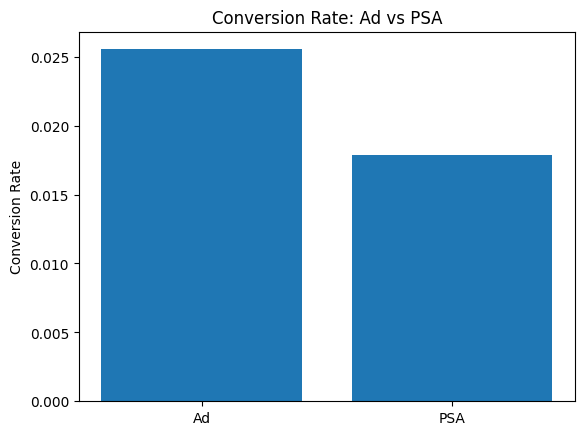

In [12]:
import matplotlib.pyplot as plt

# Conversion rates
groups = ['Ad', 'PSA']
rates = [p1, p2]

plt.bar(groups, rates)
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate: Ad vs PSA")
plt.show()

In [13]:
# Create summary dataframe

summary = pd.DataFrame({
    "Group": ["Ad", "PSA"],
    "Total Users": [ad_total, psa_total],
    "Converted Users": [ad_converted, psa_converted],
    "Conversion Rate": [p1, p2]
})

summary


,Group,Total Users,Converted Users,Conversion Rate
0,Ad,564577,14423,0.025547
1,PSA,23524,420,0.017854


In [14]:
summary.to_csv("ab_test_summary.csv", index=False)


In [15]:
with open("final_recommendation.txt", "w") as f:
    f.write("A/B Testing Analysis Result\n\n")
    f.write("Chi-square test shows a statistically significant difference in conversion rates.\n")
    f.write("P-value is less than 0.05, so we reject the null hypothesis.\n\n")
    f.write("Ad conversion rate: {:.2%}\n".format(p1))
    f.write("PSA conversion rate: {:.2%}\n".format(p2))
    f.write("Estimated improvement: {:.2%}\n".format(diff))
    f.write("95% Confidence Interval: ({:.2%}, {:.2%})\n".format(lower, upper))
    f.write("\nBusiness Recommendation: Continue running the ad campaign as it significantly improves conversions.")
